# Chapter 1

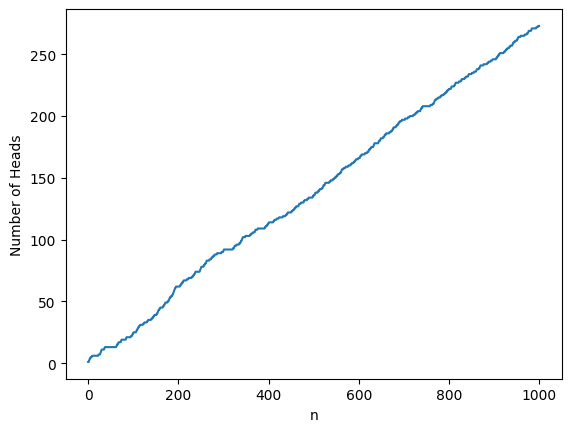

In [1]:
# Task 21
import numpy as np
import matplotlib.pyplot as plt
p = 0.3
heads = []
for i  in range(1001):
    z = np.random.rand() 
    if z < p:
        heads.append(1)
    else:
        heads.append(0)

hd = np.cumsum(heads)


plt.plot(hd, label='Number of Heads')
plt.xlabel('n')
plt.ylabel('Number of Heads')
plt.show()

At n: 10: 8.9965
Theory np: 9.0
Difference 0.0035000000000007248

At n: 100: 90.0384
Theory np: 90.0
Difference 0.03839999999999577

At n: 1000: 899.8454
Theory np: 900.0
Difference 0.15459999999995944



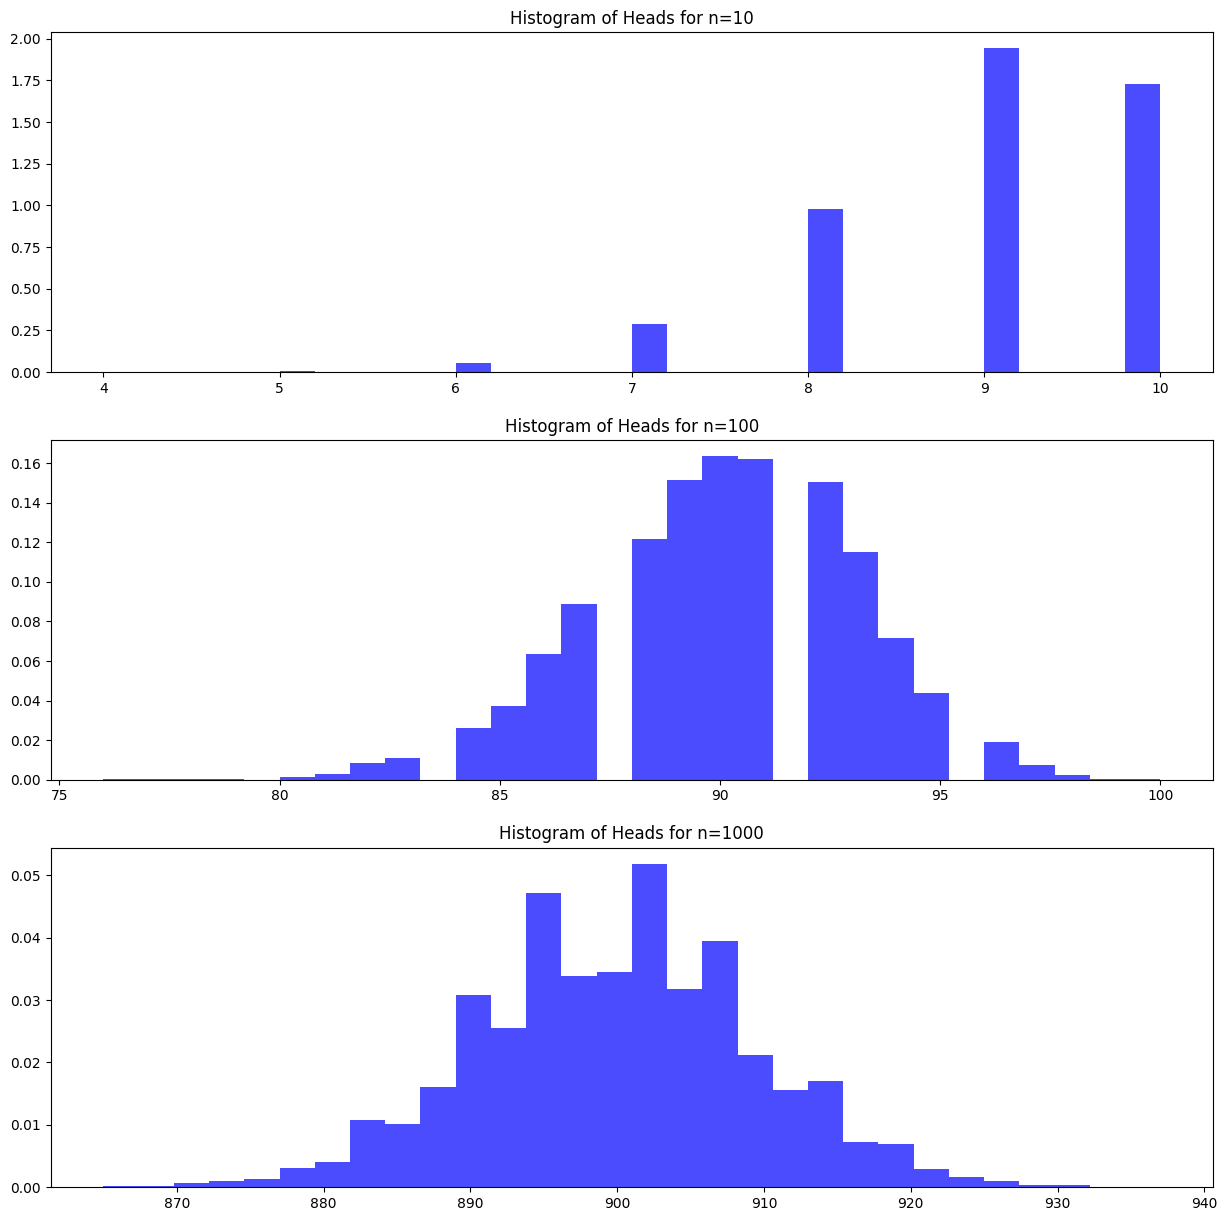

In [2]:
# Task 22

p = 0.9
ns = [10, 100, 1000]
plt.figure(figsize=(15, 15))
plt.subplot(3, 1, 1)
for n in ns:

    general_heads = []
    for i in range(10000):
        heads = 0
        for i in range(n):
            z = np.random.rand()
            if z < p:
                heads += 1
        general_heads.append(heads)
    
    plt.subplot(3, 1, ns.index(n)+1)
    plt.hist(general_heads, bins=30, density=True, alpha=0.7, color='blue')
    plt.title(f'Histogram of Heads for n={n}')
    
    
    average = sum(general_heads)/len(general_heads)

    print(f"At n: {n}: {average}")
    print(f"Theory np: {n*p}")
    print(f"Difference {np.abs(average - n*p)}\n")


In [3]:
# Task 23

res = [1,2,3,4,5,6]
n = 10000
A = 0
B = 0

for i in range(n):
    c = np.random.choice(res)
    if c in [2,4,6]:
        A += 1
    if c in [1,2,3,4]:
        B += 1
print(f"Probability of A: {A/n}")
print(f"Probability of B: {B/n}")


Probability of A: 0.4981
Probability of B: 0.6717


In [4]:
# 1. Setup the experiment
n_simulations = 100_000
rolls = np.random.randint(1, 7, n_simulations)  # Roll a die (1-6) n times

# 2. Define the Events
# Event A: Number is <= 3
event_a = (rolls <= 3)

# Event B: Number is Even (rolls % 2 == 0)
event_b = (rolls % 2 == 0)

# Event A AND B: Both conditions are true
event_a_and_b = (event_a & event_b)

# 3. Calculate Probabilities (Proportions)
# The mean of a boolean array gives the proportion of Trues
prob_a_sim = np.mean(event_a)
prob_b_sim = np.mean(event_b)
prob_ab_sim = np.mean(event_a_and_b)

# 4. Calculate Theoretical Values for comparison
prob_a_theo = 3/6
prob_b_theo = 3/6
prob_ab_theo = 1/6 

# 5. Report Results
print(f"{'Metric':<20} | {'Simulated':<10} | {'Theoretical':<10}")
print("-" * 46)
print(f"{'P(A)':<20} | {prob_a_sim:<10.4f} | {prob_a_theo:<10.4f}")
print(f"{'P(B)':<20} | {prob_b_sim:<10.4f} | {prob_b_theo:<10.4f}")
print(f"{'P(AB)':<20} | {prob_ab_sim:<10.4f} | {prob_ab_theo:<10.4f}")
print("-" * 46)

Metric               | Simulated  | Theoretical
----------------------------------------------
P(A)                 | 0.4995     | 0.5000    
P(B)                 | 0.5009     | 0.5000    
P(AB)                | 0.1662     | 0.1667    
----------------------------------------------


In [1]:
from scipy.stats import norm
# inverse of normal cdf

#c 3+norm.ppf(0.95)*4
#d 
# norm.cdf(1/4) - norm.cdf(-3/4) OR
# norm.cdf(4, loc=3, scale=4) - norm.cdf(0, loc=3, scale=4)
norm.cdf(-1)


np.float64(0.15865525393145707)

# Chapter 3

Text(0, 0.5, 'Average of samples')

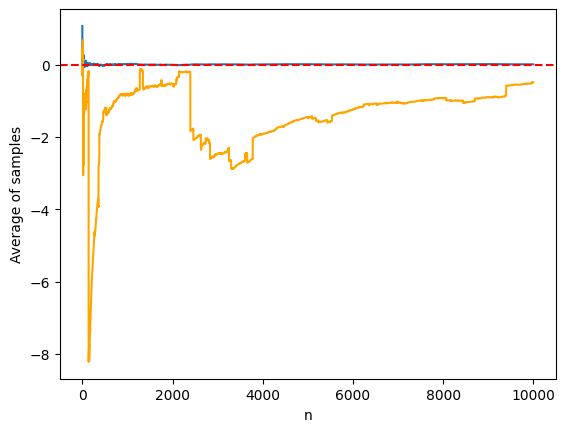

In [28]:
# task 9


xs = []
avgs = []
x_cauchy = []
avgs_cauchy = []
for i in range(1,10000):
    z = np.random.normal(0,1)
    xs.append(z)
    avgs.append(np.mean(xs))
    z_c = np.random.standard_cauchy()
    x_cauchy.append(z_c)
    avgs_cauchy.append(np.mean(x_cauchy))

plt.plot(avgs)
plt.plot(avgs_cauchy, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('n')
plt.ylabel('Average of samples')



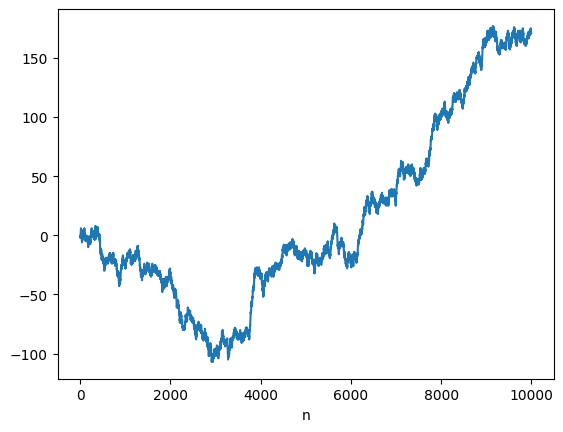

In [32]:
# Task 11

# P(y=1) = p(y=-1) = 0.4
# Xn = sum(yi)

ys = []
xs = []
for i in range(1,10_000):
    y = np.random.choice([-1,1])
    ys.append(y)
    xs.append(np.sum(ys))

plt.plot(xs)
plt.xlabel('n')
plt.show()


Given $n$ independent and identically distributed (IID) samples ${x_1, x_2, \dots, x_n}$, the likelihood function $L(\lambda)$ is the product of the individual probability density functions:

$$L(\lambda) = \prod_{i=1}^{n} f(x_i; \lambda) = \prod_{i=1}^{n} \frac{1}{24} \lambda^5 x_i^4 e^{-\lambda x_i}$$

Using the properties of exponents and products, we can simplify this:

$$L(\lambda) = \left( \frac{1}{24} \right)^n \lambda^{5n} \left( \prod_{i=1}^{n} x_i^4 \right) e^{-\lambda \sum_{i=1}^{n} x_i}$$
2. The Log-Likelihood Function

It is easier to maximize the natural logarithm of the likelihood function, $\ell(\lambda) = \ln L(\lambda)$, because it turns products into sums:

$$\ell(\lambda) = \ln \left[ \left( \frac{1}{24} \right)^n \lambda^{5n} \left( \prod_{i=1}^{n} x_i^4 \right) e^{-\lambda \sum_{i=1}^{n} x_i} \right]$$

Applying logarithm rules ($\ln(ab) = \ln a + \ln b$ and $\ln(a^b) = b \ln a$):

$$\ell(\lambda) = n \ln\left(\frac{1}{24}\right) + 5n \ln(\lambda) + 4 \sum_{i=1}^{n} \ln(x_i) - \lambda \sum_{i=1}^{n} x_i$$
3. Differentiate with respect to $\lambda$

To find the maximum, we take the partial derivative of $\ell(\lambda)$ with respect to $\lambda$:

$$\frac{\partial \ell}{\partial \lambda} = \frac{\partial}{\partial \lambda} \left[ n \ln\left(\frac{1}{24}\right) + 5n \ln(\lambda) + 4 \sum_{i=1}^{n} \ln(x_i) - \lambda \sum_{i=1}^{n} x_i \right]$$

The terms that do not contain $\lambda$ derive to zero:

$$\frac{\partial \ell}{\partial \lambda} = \frac{5n}{\lambda} - \sum_{i=1}^{n} x_i$$
4. Solve for $\hat{\lambda}$

Set the derivative equal to zero to find the critical point $\hat{\lambda}$:

$$\frac{5n}{\hat{\lambda}} - \sum_{i=1}^{n} x_i = 0$$

$$\frac{5n}{\hat{\lambda}} = \sum_{i=1}^{n} x_i$$

$$\hat{\lambda} = \frac{5n}{\sum_{i=1}^{n} x_i}$$

Using the definition of the sample mean, $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$, we can rewrite this as:

$$\hat{\lambda} = \frac{5}{\bar{x}}$$
5. Verify the Maximum

To ensure this critical point is a maximum, we check the second derivative:

$$\frac{\partial^2 \ell}{\partial \lambda^2} = -\frac{5n}{\lambda^2}$$

Since $n > 0$ and $\lambda^2 > 0$, the second derivative is always negative ($< 0$), confirming that the log-likelihood function is concave and $\hat{\lambda}$ is indeed a maximum.

Final Answer: The maximum likelihood estimate for $\lambda$ is: $$\hat{\lambda} = \frac{5n}{\sum_{i=1}^n x_i} = \frac{5}{\bar{x}}$$